# Détection d'anomalies sur commissions et frais — Orange Money

**Auteur :** Koceila SALEM — Direction RA&FM

## Contexte spécifique : la plupart des transactions sont gratuites

L'analyse des données Orange Money Madagascar a révélé un fait essentiel pour la modélisation :

| Colonne | % de zéros |
|---|---|
| `COMMISSIONS_PAID` | 62% |
| `COMMISSIONS_RECEIVED` | 99.8% |
| `SERVICE_CHARGE_RECEIVED` | 77% |
| `TAXES` | 100% |

**La majorité des transactions sont gratuites.** Cela invalide l'approche naïve (Isolation Forest sur les valeurs brutes) qui apprendrait que `commission = 0` est normal et masquerait les vraies anomalies.

## Approche : détection à 3 niveaux

Pour chaque triplet `(jour, SERVICE_TYPE, profil_tarification)` — où `profil_tarification ∈ {gratuit, commissionné}` :

1. **Anomalie de facturation** — un service qui devrait être gratuit et qui ne l'est plus, ou inversement
2. **Anomalie de ratio** — sur les transactions commissionnées, le ratio `commission/montant` dévie de la norme
3. **Anomalie de drift** — proportion de transactions commissionnées qui change brutalement

Chaque triplet reçoit un score composite, et les top alertes sont remontées avec une explication métier.

---

## 1. Imports et configuration

In [6]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100

# === PARAMÈTRES — à ajuster selon ton environnement ===
CSV_PATH = r'C:\Users\RQKB6834\Downloads\OM_Koceila\OM_Koceila.csv.csv'
OUTPUT_DIR = Path('./outputs_modele4')
OUTPUT_DIR.mkdir(exist_ok=True)

# Lecture CSV (validés au notebook 01)
ENCODING = 'latin-1'
SEPARATEUR = '|'
CHUNK_SIZE = 1_000_000
DATE_FORMAT = '%d/%m/%Y %H:%M:%S'

# Périmètre métier
SERVICES_METIER = ['RC', 'MERCHPAY', 'CASHIN', 'CASHOUT', 'P2P', 'B2BCASHOUT']

# Hyperparamètres modèle
CONTAMINATION = 0.05  # 5% d'anomalies attendues
RANDOM_STATE = 42

print(f'CSV : {CSV_PATH}')
print(f'Output : {OUTPUT_DIR.resolve()}')

CSV : C:\Users\RQKB6834\Downloads\OM_Koceila\OM_Koceila.csv.csv
Output : C:\Users\RQKB6834\OneDrive - orange.com\Bureau\Alternance\ML\outputs_modele4


## 2. Lecture out-of-core et agrégation

Le CSV fait 13 Go, on le lit par chunks de 1M de lignes. Pour chaque chunk, on filtre le périmètre métier et on agrège selon notre clé de groupe.

**Clé de groupe choisie :** `(date, SERVICE_TYPE, profil_tarification)` où `profil_tarification` distingue les transactions gratuites des transactions commissionnées. Cette segmentation permet d'analyser séparément les deux populations.

In [7]:
def classer_profil(row):
    """Détermine si une transaction est gratuite ou commissionnée.
    
    Une transaction est dite 'commissionnée' si au moins UN des flux
    de commission/frais est non nul. Sinon elle est 'gratuite'.
    """
    total_com = (
        row['COMMISSIONS_PAID'] + row['COMMISSIONS_RECEIVED']
        + row['SERVICE_CHARGE_RECEIVED'] + row['SERVICE_CHARGE_PAID']
    )
    return 'commissionne' if total_com > 0 else 'gratuit'


def traiter_chunk(chunk):
    """Filtre, classe et agrège un chunk.
    
    Retourne un DataFrame agrégé par (date, SERVICE_TYPE, profil_tarification).
    """
    # Filtre périmètre métier (TS uniquement, services métier)
    chunk = chunk[
        (chunk['TRANSFER_STATUS'] == 'TS')
        & (chunk['IS_FINANCIAL'] == 'Y')
        & (chunk['SERVICE_TYPE'].isin(SERVICES_METIER))
    ]
    if len(chunk) == 0:
        return None
    
    chunk = chunk.copy()
    
    # Date au niveau jour
    chunk['CREATED_ON'] = pd.to_datetime(
        chunk['CREATED_ON'], format=DATE_FORMAT, errors='coerce'
    )
    chunk = chunk.dropna(subset=['CREATED_ON'])
    chunk['date'] = chunk['CREATED_ON'].dt.date
    
    # Classification du profil de tarification (vectorisée)
    total_com = (
        chunk['COMMISSIONS_PAID'] + chunk['COMMISSIONS_RECEIVED']
        + chunk['SERVICE_CHARGE_RECEIVED'] + chunk['SERVICE_CHARGE_PAID']
    )
    chunk['profil'] = np.where(total_com > 0, 'commissionne', 'gratuit')
    
    # Agrégation
    agg = chunk.groupby(['date', 'SERVICE_TYPE', 'profil'], observed=True).agg(
        nb_tx=('TRANSACTION_AMOUNT', 'count'),
        sum_amount=('TRANSACTION_AMOUNT', 'sum'),
        sumsq_amount=('TRANSACTION_AMOUNT', lambda x: (x**2).sum()),
        sum_com_paid=('COMMISSIONS_PAID', 'sum'),
        sum_com_received=('COMMISSIONS_RECEIVED', 'sum'),
        sum_charge_received=('SERVICE_CHARGE_RECEIVED', 'sum'),
        sum_charge_paid=('SERVICE_CHARGE_PAID', 'sum'),
    ).reset_index()
    return agg

In [8]:
from pathlib import Path

# Colonnes nécessaires + dtypes optimisés (économise la RAM)
USECOLS = [
    'TRANSACTION_AMOUNT', 'COMMISSIONS_PAID', 'COMMISSIONS_RECEIVED',
    'SERVICE_CHARGE_RECEIVED', 'SERVICE_CHARGE_PAID',
    'SERVICE_TYPE', 'TRANSFER_STATUS', 'IS_FINANCIAL',
    'CREATED_ON',
]
DTYPES = {
    'TRANSACTION_AMOUNT': 'float32',
    'COMMISSIONS_PAID': 'float32',
    'COMMISSIONS_RECEIVED': 'float32',
    'SERVICE_CHARGE_RECEIVED': 'float32',
    'SERVICE_CHARGE_PAID': 'float32',
    'SERVICE_TYPE': 'category',
    'TRANSFER_STATUS': 'category',
    'IS_FINANCIAL': 'category',
}

# Estimation pour la barre de progression
NB_LIGNES_TOTAL = 25_456_467
nb_chunks_estime = NB_LIGNES_TOTAL // CHUNK_SIZE + 1

# Boucle principale
agregats = []
lignes_lues = 0
debut = time.time()

csv_path = Path(CSV_PATH)
if not csv_path.exists():
    print(f"⚠ Fichier introuvable : {csv_path}")
    print(f"Chemin recherché : {csv_path}")
    
    # Affiche les fichiers dans le dossier parent
    parent_dir = csv_path.parent
    if parent_dir.exists():
        print(f"\nFichiers dans {parent_dir.name}:")
        for f in parent_dir.glob('*.csv'):
            print(f"  - {f.name} ({f.stat().st_size / 1024 / 1024:.1f} Mo)")
    else:
        print(f"Le dossier parent n'existe pas : {parent_dir}")
    
    raise FileNotFoundError(
        f"Fichier introuvable : {csv_path}\n"
        "Corrige CSV_PATH ou utilise le chemin trouvé ci-dessus."
    )

reader = pd.read_csv(
    csv_path,
    sep=SEPARATEUR, encoding=ENCODING,
    usecols=USECOLS, dtype=DTYPES, chunksize=CHUNK_SIZE,
    low_memory=False, on_bad_lines='warn',
)

for chunk in tqdm(reader, total=nb_chunks_estime, desc='Lecture chunks'):
    lignes_lues += len(chunk)
    agg = traiter_chunk(chunk)
    if agg is not None:
        agregats.append(agg)

duree = time.time() - debut
print(f'\n✓ {lignes_lues:,} lignes lues en {duree/60:.1f} min')
print(f'  {len(agregats)} agrégats partiels collectés')

Lecture chunks:   0%|          | 0/26 [00:00<?, ?it/s]

Lecture chunks: 100%|██████████| 26/26 [04:48<00:00, 11.10s/it]


✓ 25,456,467 lignes lues en 4.8 min
  26 agrégats partiels collectés


In [9]:
# Fusion finale : on regroupe les agrégats partiels (qui partagent les mêmes clés)
df = pd.concat(agregats, ignore_index=True)
cols_sum = [c for c in df.columns if c not in ['date', 'SERVICE_TYPE', 'profil']]
df = df.groupby(['date', 'SERVICE_TYPE', 'profil'], observed=True)[cols_sum].sum().reset_index()
df['date'] = pd.to_datetime(df['date'])

print(f'Dataset agrégé : {len(df):,} lignes')
print(f'  Plage : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  Services : {sorted(df["SERVICE_TYPE"].unique().tolist())}')
print(f'  Profils : {sorted(df["profil"].unique().tolist())}')

# Sauvegarde Parquet pour ne pas avoir à relire le CSV plus tard
parquet_path = OUTPUT_DIR / 'aggregated_jour_service_profil.parquet'
df.to_parquet(parquet_path, compression='snappy')
print(f'\n✓ Sauvegardé : {parquet_path} ({parquet_path.stat().st_size / 1024:.0f} Ko)')

df.head(10)

Dataset agrégé : 330 lignes
  Plage : 2025-09-01 → 2025-09-30
  Services : ['B2BCASHOUT', 'CASHIN', 'CASHOUT', 'MERCHPAY', 'P2P', 'RC']
  Profils : ['commissionne', 'gratuit']

✓ Sauvegardé : outputs_modele4\aggregated_jour_service_profil.parquet (15 Ko)


,date,SERVICE_TYPE,profil,nb_tx,sum_amount,sumsq_amount,sum_com_paid,sum_com_received,sum_charge_received,sum_charge_paid
0,2025-09-01,B2BCASHOUT,commissionne,174,99291664.0000,346580641120256.0000,357545.0000,0.0000,899775.0000,0.0000
1,2025-09-01,CASHIN,commissionne,96445,13383035904.0000,21531766271508480.0000,33322684.0000,12076.0000,27836456.0000,0.0000
2,2025-09-01,CASHIN,gratuit,58316,9969890304.0000,16186195214073856.0000,0.0000,0.0000,0.0000,0.0000
3,2025-09-01,CASHOUT,commissionne,136547,17379704832.0000,23717571765207040.0000,99979648.0000,0.0000,242538368.0000,0.0000
4,2025-09-01,CASHOUT,gratuit,10291,1166022016.0000,887471978053632.0000,0.0000,0.0000,0.0000,0.0000
5,2025-09-01,MERCHPAY,commissionne,10107,1413103232.0000,2794805549596672.0000,0.0000,110151.9375,10256541.0000,0.0000
6,2025-09-01,MERCHPAY,gratuit,179341,2030319360.0000,4636167551057920.0000,0.0000,0.0000,0.0000,0.0000
7,2025-09-01,P2P,commissionne,86487,13692771328.0000,124170777292439552.0000,1892329.7500,92024.0000,78448008.0000,0.0000
8,2025-09-01,P2P,gratuit,17763,30177392640.0000,1557819410314428416.0000,0.0000,0.0000,0.0000,0.0000
9,2025-09-01,RC,commissionne,151783,186314992.0000,1591548968960.0000,8407049.0000,0.0000,0.0000,0.0000


## 3. Construction des features

On calcule trois familles de features :

- **Volumes** : volume moyen, écart-type, total
- **Ratios financiers** : rapport commission/montant, marge nette par transaction
- **Drift** : proportion gratuit/commissionné par jour

In [10]:
def safe_div(num, denom):
    """Division robuste aux zéros."""
    return np.where(denom != 0, num / denom.replace(0, np.nan), 0)


# --- Volumes ---
df['volume_moyen'] = df['sum_amount'] / df['nb_tx']
variance = (df['sumsq_amount'] / df['nb_tx']) - df['volume_moyen']**2
df['volume_std'] = np.sqrt(np.maximum(variance, 0)).fillna(0)

# --- Ratios financiers (significatifs surtout pour le profil 'commissionne') ---
df['taux_charge_recue'] = safe_div(df['sum_charge_received'], df['sum_amount'])
df['taux_com_payee'] = safe_div(df['sum_com_paid'], df['sum_amount'])
df['taux_charge_payee'] = safe_div(df['sum_charge_paid'], df['sum_amount'])

# --- Marge nette (formule OM Madagascar) ---
df['revenu_net'] = df['sum_charge_received'] - df['sum_com_paid'] - df['sum_charge_paid']
df['marge_par_tx'] = df['revenu_net'] / df['nb_tx']

# --- Drift : part de chaque profil dans le service ce jour-là ---
total_jour_service = df.groupby(['date', 'SERVICE_TYPE'], observed=True)['nb_tx'].transform('sum')
df['part_profil'] = df['nb_tx'] / total_jour_service

# --- Saisonnalité légère (1 mois donc peu de variabilité, on garde juste jour_semaine) ---
df['jour_semaine'] = df['date'].dt.dayofweek
df['est_weekend'] = (df['jour_semaine'] >= 5).astype(int)

# Clipping de sécurité sur les ratios (évite que les outliers extrêmes ne brouillent l'IF)
for col in ['taux_charge_recue', 'taux_com_payee', 'taux_charge_payee']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0).clip(-2, 2)

print(f'Features construites : {len(df.columns)} colonnes')
df.head(8)

Features construites : 20 colonnes


,date,SERVICE_TYPE,profil,nb_tx,sum_amount,sumsq_amount,sum_com_paid,sum_com_received,sum_charge_received,sum_charge_paid,volume_moyen,volume_std,taux_charge_recue,taux_com_payee,taux_charge_payee,revenu_net,marge_par_tx,part_profil,jour_semaine,est_weekend
0,2025-09-01,B2BCASHOUT,commissionne,174,99291664.0000,346580641120256.0000,357545.0000,0.0000,899775.0000,0.0000,570641.7471,1290817.8653,0.0091,0.0036,0.0000,542230.0000,3116.2644,1.0000,0,0
1,2025-09-01,CASHIN,commissionne,96445,13383035904.0000,21531766271508480.0000,33322684.0000,12076.0000,27836456.0000,0.0000,138763.3978,451662.5670,0.0021,0.0025,0.0000,-5486228.0000,-56.8845,0.6232,0,0
2,2025-09-01,CASHIN,gratuit,58316,9969890304.0000,16186195214073856.0000,0.0000,0.0000,0.0000,0.0000,170963.2057,498328.8970,0.0000,0.0000,0.0000,0.0000,0.0000,0.3768,0,0
3,2025-09-01,CASHOUT,commissionne,136547,17379704832.0000,23717571765207040.0000,99979648.0000,0.0000,242538368.0000,0.0000,127280.0196,396856.5156,0.0140,0.0058,0.0000,142558720.0000,1044.0267,0.9299,0,0
4,2025-09-01,CASHOUT,gratuit,10291,1166022016.0000,887471978053632.0000,0.0000,0.0000,0.0000,0.0000,113305.0254,270923.7024,0.0000,0.0000,0.0000,0.0000,0.0000,0.0701,0,0
5,2025-09-01,MERCHPAY,commissionne,10107,1413103232.0000,2794805549596672.0000,0.0000,110151.9375,10256541.0000,0.0000,139814.3101,506925.7645,0.0073,0.0000,0.0000,10256541.0000,1014.7958,0.0533,0,0
6,2025-09-01,MERCHPAY,gratuit,179341,2030319360.0000,4636167551057920.0000,0.0000,0.0000,0.0000,0.0000,11320.9994,160383.8060,0.0000,0.0000,0.0000,0.0000,0.0000,0.9467,0,0
7,2025-09-01,P2P,commissionne,86487,13692771328.0000,124170777292439552.0000,1892329.7500,92024.0000,78448008.0000,0.0000,158321.7284,1187708.0105,0.0057,0.0001,0.0000,76555680.0000,885.1698,0.8296,0,0


## 4. Détection à 3 niveaux

Plutôt qu'un seul Isolation Forest sur tout le dataset, on combine trois signaux complémentaires.

### Niveau 1 — Anomalie de facturation (catégorielle)

Pour chaque service, on regarde la part habituelle de transactions commissionnées vs gratuites. Une journée où cette part dévie fortement est suspecte.

Exemple typique : un service comme P2P qui passe de 99% gratuit à 60% gratuit du jour au lendemain → soit un bug applicatif, soit un changement tarifaire non documenté.

In [11]:
# Pour chaque (service, profil), part habituelle (médiane sur la période)
ref_part = df.groupby(['SERVICE_TYPE', 'profil'], observed=True)['part_profil'].median().to_dict()

# Z-score robuste (médiane + MAD) sur la part_profil par groupe
def mad(x):
    return np.median(np.abs(x - x.median()))

stats_part = df.groupby(['SERVICE_TYPE', 'profil'], observed=True).agg(
    median_part=('part_profil', 'median'),
    mad_part=('part_profil', mad),
).to_dict('index')

def z_facturation(row):
    key = (row['SERVICE_TYPE'], row['profil'])
    s = stats_part.get(key, {})
    med, m = s.get('median_part', 0), s.get('mad_part', 0)
    denom = 1.4826 * m
    return (row['part_profil'] - med) / denom if denom > 0 else 0

df['z_facturation'] = df.apply(z_facturation, axis=1).fillna(0)

# Affichage du top 5
print('Top 5 anomalies de facturation (|z| max) :')
top_fact = df.reindex(df['z_facturation'].abs().sort_values(ascending=False).index).head(5)
top_fact[['date', 'SERVICE_TYPE', 'profil', 'part_profil', 'z_facturation']]

Top 5 anomalies de facturation (|z| max) :


,date,SERVICE_TYPE,profil,part_profil,z_facturation
179,2025-09-17,CASHOUT,commissionne,0.6938,-30.2541
180,2025-09-17,CASHOUT,gratuit,0.3062,30.2541
190,2025-09-18,CASHOUT,commissionne,0.7421,-24.2244
191,2025-09-18,CASHOUT,gratuit,0.2579,24.2244
228,2025-09-21,P2P,gratuit,0.0781,-5.4725


### Niveau 2 — Anomalie de ratio (Isolation Forest sur le profil commissionné)

**Important :** on n'entraîne le modèle ML QUE sur les lignes où `profil = 'commissionne'`. Pourquoi ? Parce que les ratios `commission/montant` n'ont aucun sens sur les transactions gratuites (elles seraient toutes à 0). Mélanger les deux populations brouillerait le signal.

In [12]:
df_com = df[df['profil'] == 'commissionne'].copy()
print(f'Sous-ensemble commissionné : {len(df_com)} lignes ({len(df_com)/len(df)*100:.1f}% du dataset)')

# Features pour IF : ratios + volumes (sans la part_profil qui est déjà couverte par niveau 1)
FEATURES_IF = [
    'taux_charge_recue', 'taux_com_payee', 'taux_charge_payee',
    'volume_moyen', 'volume_std', 'marge_par_tx',
    'jour_semaine',
]

# One-hot du service pour que l'IF apprenne des patterns par service
df_com_enc = pd.get_dummies(df_com, columns=['SERVICE_TYPE'], prefix='svc')
feature_cols = FEATURES_IF + [c for c in df_com_enc.columns if c.startswith('svc_')]
X = df_com_enc[feature_cols].values

# Scaling robuste (résiste aux outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Entraînement
iforest = IsolationForest(
    n_estimators=200, contamination=CONTAMINATION,
    random_state=RANDOM_STATE, n_jobs=-1,
)
iforest.fit(X_scaled)

# Scoring : on remet le score sur df_com (pas df global)
df_com['score_ratio'] = -iforest.score_samples(X_scaled)
df_com['anomalie_ratio'] = (iforest.predict(X_scaled) == -1).astype(int)

# Réinjection dans le df global (les lignes 'gratuit' auront score_ratio=0)
df = df.merge(
    df_com[['date', 'SERVICE_TYPE', 'profil', 'score_ratio', 'anomalie_ratio']],
    on=['date', 'SERVICE_TYPE', 'profil'], how='left',
)
df['score_ratio'] = df['score_ratio'].fillna(0)
df['anomalie_ratio'] = df['anomalie_ratio'].fillna(0).astype(int)

print(f'\nAnomalies de ratio détectées : {df["anomalie_ratio"].sum()} sur {len(df)} lignes')

Sous-ensemble commissionné : 180 lignes (54.5% du dataset)

Anomalies de ratio détectées : 9 sur 330 lignes


### Niveau 3 — Anomalie de drift agrégé

On surveille le revenu net global de chaque service par jour. Une chute brutale = signal de fuite, même si chaque transaction prise isolément paraît normale.

In [13]:
# Revenu net total par (jour, service)
drift = df.groupby(['date', 'SERVICE_TYPE'], observed=True).agg(
    revenu_jour=('revenu_net', 'sum'),
    nb_tx_jour=('nb_tx', 'sum'),
).reset_index()
drift['revenu_par_tx'] = drift['revenu_jour'] / drift['nb_tx_jour']

# Z-score robuste par service
stats_drift = drift.groupby('SERVICE_TYPE', observed=True).agg(
    median_rev=('revenu_par_tx', 'median'),
    mad_rev=('revenu_par_tx', mad),
).to_dict('index')

def z_drift_revenu(row):
    s = stats_drift.get(row['SERVICE_TYPE'], {})
    med, m = s.get('median_rev', 0), s.get('mad_rev', 0)
    denom = 1.4826 * m
    return (row['revenu_par_tx'] - med) / denom if denom > 0 else 0

drift['z_drift'] = drift.apply(z_drift_revenu, axis=1).fillna(0)

# Réinjection dans df
df = df.merge(drift[['date', 'SERVICE_TYPE', 'z_drift']], on=['date', 'SERVICE_TYPE'], how='left')
df['z_drift'] = df['z_drift'].fillna(0)

print('Top 5 services-jours avec drift de revenu :')
drift.reindex(drift['z_drift'].abs().sort_values(ascending=False).index).head(5)

Top 5 services-jours avec drift de revenu :


,date,SERVICE_TYPE,revenu_jour,nb_tx_jour,revenu_par_tx,z_drift
125,2025-09-21,RC,-4680953.0000,202567,-23.1082,8.3310
41,2025-09-07,RC,-4724753.5000,204337,-23.1224,8.3111
83,2025-09-14,RC,-4694022.0000,198381,-23.6617,7.5538
167,2025-09-28,RC,-5535769.0000,221326,-25.0118,5.6577
173,2025-09-29,RC,-8321039.5000,258997,-32.1279,-4.3354


## 5. Score composite et statut

On combine les 3 signaux en un score global. Chaque ligne reçoit aussi une explication textuelle de l'alerte.

In [14]:
# Score composite : max des 3 signaux normalisés
df['score_composite'] = (
    df[['z_facturation', 'score_ratio', 'z_drift']]
    .abs().max(axis=1)
)

# Seuils
SEUIL_ALERTE = 2.5
SEUIL_CRITIQUE = 3.5

def statut(s):
    if s >= SEUIL_CRITIQUE:
        return 'CRITIQUE'
    if s >= SEUIL_ALERTE:
        return 'ALERTE'
    return 'NORMAL'

df['statut'] = df['score_composite'].apply(statut)

# Explication textuelle automatique
def explication(row):
    parts = []
    if abs(row['z_facturation']) >= 2:
        sens = 'plus' if row['z_facturation'] > 0 else 'moins'
        parts.append(f"part {row['profil']} {sens} fréquente que d'habitude (z={row['z_facturation']:+.1f})")
    if row['anomalie_ratio'] == 1:
        parts.append(f"ratio commission/montant atypique (score={row['score_ratio']:.2f})")
    if abs(row['z_drift']) >= 2:
        sens = 'hausse' if row['z_drift'] > 0 else 'baisse'
        parts.append(f"{sens} anormale du revenu net global (z={row['z_drift']:+.1f})")
    return ' | '.join(parts) if parts else 'comportement nominal'

df['explication'] = df.apply(explication, axis=1)

# Synthèse
print('Répartition des statuts :')
print(df['statut'].value_counts())
print(f'\n→ {(df["statut"] != "NORMAL").sum()} alertes sur {len(df)} lignes ({(df["statut"] != "NORMAL").mean()*100:.1f}%)')

Répartition des statuts :
statut
NORMAL      280
ALERTE       28
CRITIQUE     22
Name: count, dtype: int64

→ 50 alertes sur 330 lignes (15.2%)


## 6. Quantification du montant à risque

Pour chaque alerte, on estime le manque à gagner = `(revenu attendu - revenu observé) × nb_transactions`.  
Le revenu attendu est la médiane historique du couple `(service, profil)`.

In [15]:
# Référence : marge médiane par (service, profil)
ref_marge = df.groupby(['SERVICE_TYPE', 'profil'], observed=True)['marge_par_tx'].median().to_dict()

def montant_risque(row):
    attendu = ref_marge.get((row['SERVICE_TYPE'], row['profil']), 0)
    return (attendu - row['marge_par_tx']) * row['nb_tx']

df['montant_risque_ar'] = df.apply(montant_risque, axis=1)

alertes = df[df['statut'] != 'NORMAL'].copy().sort_values(
    ['statut', 'montant_risque_ar'], ascending=[True, False],
)

print(f'Total montant à risque sur les alertes : {alertes["montant_risque_ar"].sum():,.0f} Ar')
print(f'Top alerte : {alertes["montant_risque_ar"].max():,.0f} Ar')

alertes[['date', 'SERVICE_TYPE', 'profil', 'statut', 'score_composite',
         'montant_risque_ar', 'explication']].head(15)

Total montant à risque sur les alertes : 110,513,595 Ar
Top alerte : 19,779,832 Ar


,date,SERVICE_TYPE,profil,statut,score_composite,montant_risque_ar,explication
223,2025-09-21,CASHOUT,commissionne,ALERTE,2.9840,19779831.5571,baisse anormale du revenu net global (z=-3.0)
146,2025-09-14,CASHOUT,commissionne,ALERTE,2.9627,19623463.8883,baisse anormale du revenu net global (z=-3.0)
300,2025-09-28,CASHOUT,commissionne,ALERTE,2.9964,18510661.9449,part commissionne moins fréquente que d'habitu...
293,2025-09-27,P2P,commissionne,ALERTE,2.7519,8041414.2444,part commissionne plus fréquente que d'habitud...
148,2025-09-14,MERCHPAY,commissionne,ALERTE,2.8270,2321297.5161,baisse anormale du revenu net global (z=-2.8)
302,2025-09-28,MERCHPAY,commissionne,ALERTE,3.4703,2046711.0028,part commissionne moins fréquente que d'habitu...
71,2025-09-07,MERCHPAY,commissionne,ALERTE,3.0638,1797286.7773,part commissionne moins fréquente que d'habitu...
225,2025-09-21,MERCHPAY,commissionne,ALERTE,2.7910,1783424.1328,part commissionne moins fréquente que d'habitu...
328,2025-09-30,RC,commissionne,ALERTE,2.5755,441599.0910,baisse anormale du revenu net global (z=-2.6)
240,2025-09-22,RC,commissionne,ALERTE,3.2946,235829.0995,baisse anormale du revenu net global (z=-3.3)


## 7. Visualisations

Quatre vues complémentaires pour comprendre les alertes.

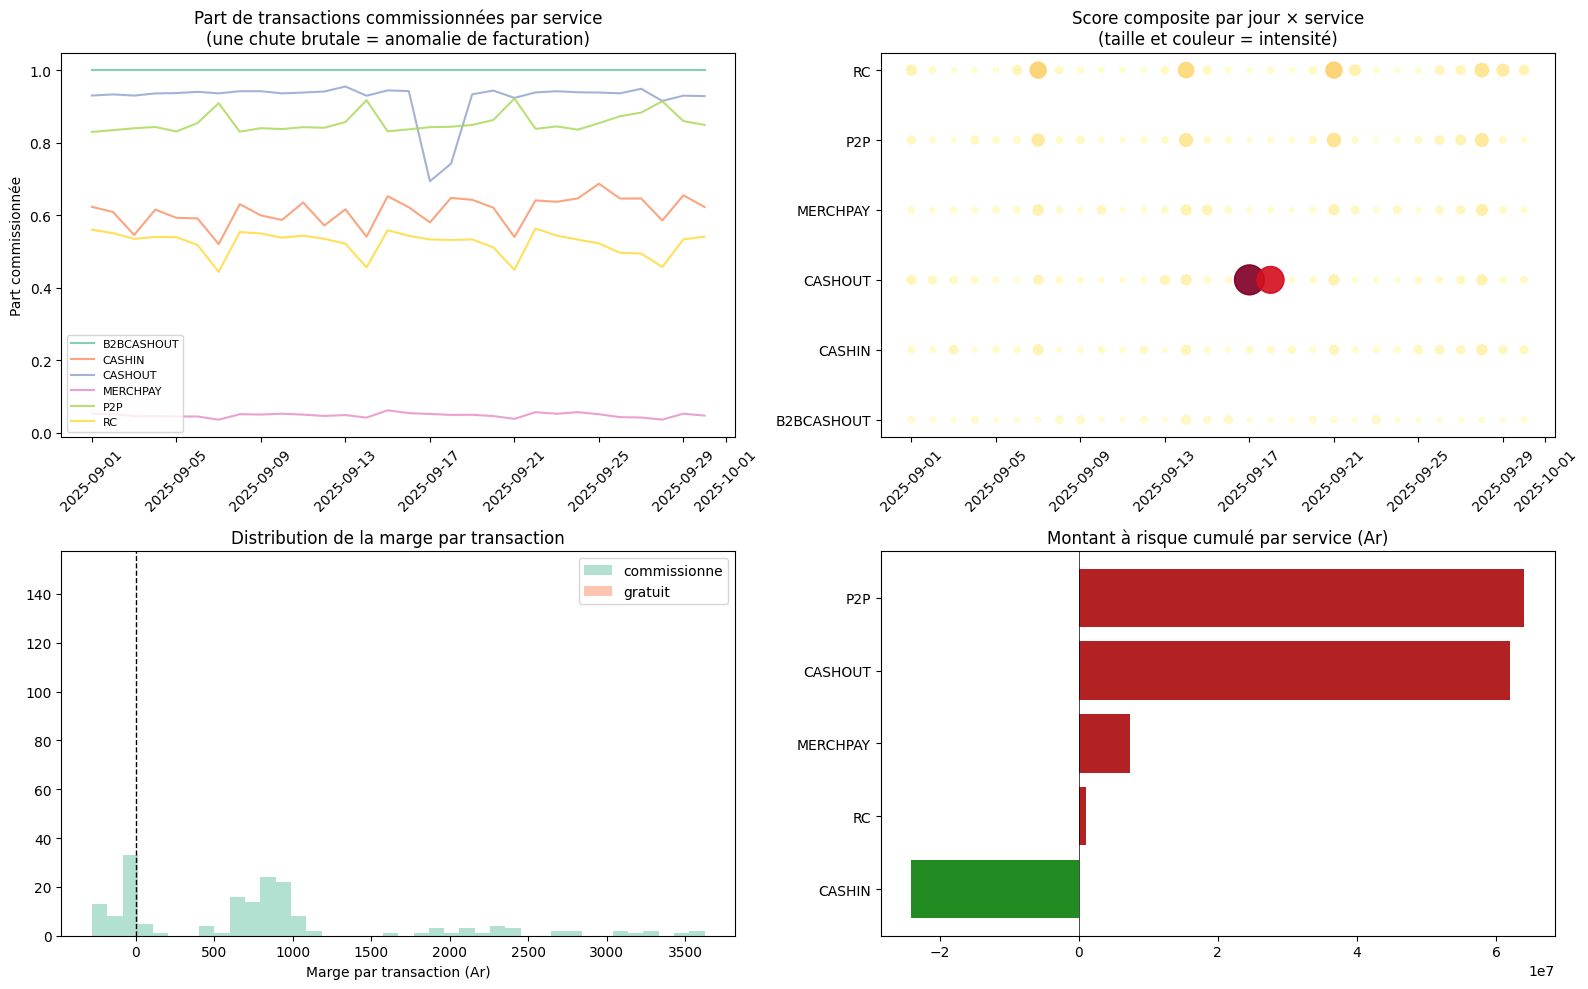


✓ Visualisation sauvegardée : outputs_modele4\dashboard_anomalies.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Évolution de la part de transactions commissionnées par service
df_com_part = df[df['profil'] == 'commissionne'].pivot_table(
    index='date', columns='SERVICE_TYPE', values='part_profil', aggfunc='mean',
)
for col in df_com_part.columns:
    axes[0, 0].plot(df_com_part.index, df_com_part[col], label=col, linewidth=1.5, alpha=0.8)
axes[0, 0].set_title('Part de transactions commissionnées par service\n(une chute brutale = anomalie de facturation)')
axes[0, 0].set_ylabel('Part commissionnée')
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].tick_params(axis='x', rotation=45)

# (2) Score composite par jour-service-profil
axes[0, 1].scatter(
    df['date'], df['SERVICE_TYPE'],
    s=df['score_composite']*15 + 5,
    c=df['score_composite'], cmap='YlOrRd', alpha=0.7,
)
axes[0, 1].set_title('Score composite par jour × service\n(taille et couleur = intensité)')
axes[0, 1].tick_params(axis='x', rotation=45)

# (3) Distribution du revenu net par tx selon profil
for profil, sub in df.groupby('profil'):
    axes[1, 0].hist(sub['marge_par_tx'], bins=40, alpha=0.5, label=profil)
axes[1, 0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1, 0].set_title('Distribution de la marge par transaction')
axes[1, 0].set_xlabel('Marge par transaction (Ar)')
axes[1, 0].legend()

# (4) Montant à risque cumulé par service
if len(alertes) > 0:
    risque_par_service = alertes.groupby('SERVICE_TYPE')['montant_risque_ar'].sum().sort_values()
    couleurs = ['firebrick' if v > 0 else 'forestgreen' for v in risque_par_service.values]
    axes[1, 1].barh(risque_par_service.index, risque_par_service.values, color=couleurs)
    axes[1, 1].axvline(0, color='black', linewidth=0.5)
    axes[1, 1].set_title('Montant à risque cumulé par service (Ar)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dashboard_anomalies.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'\n✓ Visualisation sauvegardée : {OUTPUT_DIR / "dashboard_anomalies.png"}')

## 8. Export du rapport d'alertes

In [17]:
# Rapport complet (toutes lignes avec leur statut)
cols_export = [
    'date', 'SERVICE_TYPE', 'profil', 'statut',
    'score_composite', 'z_facturation', 'score_ratio', 'z_drift',
    'nb_tx', 'sum_amount', 'revenu_net', 'marge_par_tx',
    'taux_charge_recue', 'taux_com_payee',
    'part_profil', 'montant_risque_ar', 'explication',
]

rapport = df[cols_export].sort_values(['statut', 'score_composite'], ascending=[True, False])
rapport_path = OUTPUT_DIR / 'alertes_completes.csv'
rapport.to_csv(rapport_path, index=False, encoding='utf-8-sig')

# Top alertes uniquement
top_alertes_path = OUTPUT_DIR / 'top_alertes.csv'
alertes.head(50)[cols_export].to_csv(top_alertes_path, index=False, encoding='utf-8-sig')

print(f'✓ Rapport complet : {rapport_path}')
print(f'✓ Top 50 alertes : {top_alertes_path}')
print(f'\nUtilisation :')
print('  - alertes_completes.csv : pour analyse exhaustive ou intégration dashboard')
print('  - top_alertes.csv : à présenter à un analyste senior pour validation')

✓ Rapport complet : outputs_modele4\alertes_completes.csv
✓ Top 50 alertes : outputs_modele4\top_alertes.csv

Utilisation :
  - alertes_completes.csv : pour analyse exhaustive ou intégration dashboard
  - top_alertes.csv : à présenter à un analyste senior pour validation


In [18]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Dashboard Anomalies", layout="wide")

st.title("📊 Dashboard Détection d'Anomalies - Commissions")

# Upload file
uploaded_file = st.file_uploader("Importer votre dataset CSV", type=["csv"])

if uploaded_file:
    df = pd.read_csv(uploaded_file)

    st.sidebar.header("Filtres")
    if 'TRANSACTION_AMOUNT' in df.columns:
        min_val, max_val = float(df['TRANSACTION_AMOUNT'].min()), float(df['TRANSACTION_AMOUNT'].max())
        amount_range = st.sidebar.slider("Montant transaction", min_val, max_val, (min_val, max_val))
        df = df[(df['TRANSACTION_AMOUNT'] >= amount_range[0]) & (df['TRANSACTION_AMOUNT'] <= amount_range[1])]

    st.subheader("Aperçu des données")
    st.dataframe(df.head(100))

    col1, col2 = st.columns(2)

    if 'TRANSACTION_AMOUNT' in df.columns:
        fig1 = px.histogram(df, x='TRANSACTION_AMOUNT', nbins=50, title="Distribution des montants")
        col1.plotly_chart(fig1, use_container_width=True)

    if 'COMMISSIONS_PAID' in df.columns:
        fig2 = px.box(df, y='COMMISSIONS_PAID', title="Boxplot commissions payées")
        col2.plotly_chart(fig2, use_container_width=True)

    if 'RECEIVER_USER_ID' in df.columns:
        top_receivers = df['RECEIVER_USER_ID'].value_counts().head(10).reset_index()
        top_receivers.columns = ['User', 'Count']
        fig3 = px.bar(top_receivers, x='User', y='Count', title="Top receveurs")
        st.plotly_chart(fig3, use_container_width=True)

    st.subheader("Détection simple d'anomalies")

    if 'TRANSACTION_AMOUNT' in df.columns:
        threshold = df['TRANSACTION_AMOUNT'].mean() + 3 * df['TRANSACTION_AMOUNT'].std()
        anomalies = df[df['TRANSACTION_AMOUNT'] > threshold]

        st.write(f"Seuil anomalie: {threshold:.2f}")
        st.write(f"Nombre d'anomalies détectées: {len(anomalies)}")
        st.dataframe(anomalies)

else:
    st.info("Veuillez importer un fichier CSV pour commencer.")

# Run: streamlit run app.py


2026-05-04 16:00:59.650 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 16:00:59.652 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 16:01:00.597 
  command:

    streamlit run c:\Users\RQKB6834\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-04 16:01:00.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 16:01:00.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 16:01:00.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 16:01:00.602 Thread 'MainThread': missing ScriptRunContext! This